## Week Four: Decision Tree Modeling

After setting the baseline metrics with basic linear regression model last week, I want to try out Decision Tree Modeling. 

From the Decision Tree Modeling, I'm hoping to see more visualization and also an better adjustment towards the limited feature engineering I've done so far. It will also be much easier to validate using statistical tests in the future. The ability to handle both categorical and numeric data, even though sci-kit learn currently doesn't offer categorical analysis. 

The disadvantage from using Decision Tree Modeling could be easy overfitting, which could very happen and create an anectote rather than actual predicitons. Decision trees can be unstable because small variations in the data might result in a completely different tree being generated. The model could also be bad at performing extrapolation



In [1]:
#setup

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import tree

df_trained = pd.read_csv('train_housing.csv')
df_test = pd.read_csv('test_housing.csv')

df_trained.head()
df_test.head()

**Rebuild note:** the cell that actually trained the tree was empty when this notebook was reopened
(only the setup cell above had survived, plus a `decision_tree_model.pkl` file from the earlier run). I
rebuilt the missing steps below, using the same tree settings (`max_depth=10`, `min_samples_leaf=20`,
`random_state=42`) that were saved inside that pickle file, so the model matches what was trained before.

## Prepare the features

A decision tree needs numbers, not raw text or dates, and it shouldn't see the answer hiding in a
disguised column. So before fitting anything:
- Drop `ClosePrice` itself (it's the target, not a feature) along with the date columns notebook 02
  already set aside (`CloseDate`, `ListingContractDate`, `PurchaseContractDate`, `ContractStatusChangeDate`).
- Drop the pure ID columns (`ListingKey`, `ListingKeyNumeric`, `ListingId`) — a listing's ID number
  says nothing about the home, so keeping it in just invites memorization instead of learning.
- Drop `PropertyType`, `PropertySubType`, `MlsStatus` — after filtering to single-family residential
  sales, every row has the same value in these, so they carry zero information.
- Drop the handful of rows (1 in train, 0-1 in test) where `ClosePrice` itself is missing — there's
  nothing to learn or score against without a real sale price.
- Also drop rows where `ClosePrice` is `$0` or above `$50M` — the raw data has a few clearly broken prices (one "single family residence" is listed as selling for $989.5M), and a plain regression tree is very sensitive to a handful of extreme outliers like that.
- Turn every remaining text column (city, school district, etc.) into a whole number code. Trees split
  on thresholds either way, so a numeric code works fine — no need for one-hot columns like a linear
  model would need. A missing text value becomes its own "missing" category rather than being dropped.
- Fill the leftover gaps in numeric columns (`LivingArea`, `YearBuilt`, `LotSizeAcres`, etc. — notebook
  02 only filled a few specific columns, not all of them) with that column's median from the training
  set, so a few missing values don't force us to throw the whole row away.

One thing worth flagging rather than silently fixing: `DaysOnMarket` is only knowable *after* a home
sells, so it's arguably a second leakage column like the `ListPrice` one notebook 02 already dropped.
I'm leaving it in for now since I don't know if that was an intentional feature in the original run,
but it's worth revisiting.

In [2]:
from sklearn.preprocessing import OrdinalEncoder

# Columns that should not be fed to the model (see markdown note above for why)
drop_cols = [
    'CloseDate', 'ClosePrice', 'ListingContractDate', 'PurchaseContractDate', 'ContractStatusChangeDate',
    'ListingKey', 'ListingKeyNumeric', 'ListingId',
    'PropertyType', 'PropertySubType', 'MlsStatus',
]

# Can't train or score on a row with no sale price
df_trained_clean = df_trained.dropna(subset=['ClosePrice'])
df_test_clean = df_test.dropna(subset=['ClosePrice'])
print(f"Dropped {len(df_trained) - len(df_trained_clean)} train row(s) and "
      f"{len(df_test) - len(df_test_clean)} test row(s) with a missing ClosePrice")

# Notebook 02's "impossible data" checks covered bedrooms/bathrooms/square footage/dates,
# but never sanity-checked ClosePrice itself. The raw data has a handful of clearly broken
# entries - e.g. a "single family residence" that sold for $989,500,000 - which are data
# errors, not real sales, and they wreck a regression model's error metrics disproportionately.
# $0 sales aren't real market transactions either. $50M is an extremely generous ceiling
# (even the priciest CA mansions rarely clear that through standard MLS sales) so this only
# drops the clearly-broken rows, not genuine luxury listings.
PRICE_FLOOR, PRICE_CEIL = 0, 50_000_000
before_tr, before_te = len(df_trained_clean), len(df_test_clean)
df_trained_clean = df_trained_clean[df_trained_clean['ClosePrice'].between(PRICE_FLOOR, PRICE_CEIL, inclusive='right')]
df_test_clean = df_test_clean[df_test_clean['ClosePrice'].between(PRICE_FLOOR, PRICE_CEIL, inclusive='right')]
print(f"Dropped {before_tr - len(df_trained_clean)} train row(s) and "
      f"{before_te - len(df_test_clean)} test row(s) with an implausible ClosePrice "
      f"(<=${PRICE_FLOOR:,} or >${PRICE_CEIL:,})")

y_train = df_trained_clean['ClosePrice']
y_test = df_test_clean['ClosePrice']

X_train = df_trained_clean.drop(columns=drop_cols, errors='ignore')
X_test = df_test_clean.drop(columns=drop_cols, errors='ignore')

# Note which columns are text vs. numeric before we touch either
cat_cols = X_train.select_dtypes(exclude='number').columns.tolist()
num_cols = X_train.select_dtypes(include='number').columns.tolist()

# Text -> whole-number codes (a missing value becomes its own "missing" category).
# Note: .astype(str) alone isn't enough here - pandas' newer "string" dtype keeps a
# missing value as an actual NaN even after astype(str) instead of writing out "nan"
# the way old-style object columns do, so fillna has to run first.
X_train[cat_cols] = X_train[cat_cols].fillna('missing').astype(str)
X_test[cat_cols] = X_test[cat_cols].fillna('missing').astype(str)

encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_train[cat_cols] = encoder.fit_transform(X_train[cat_cols])
X_test[cat_cols] = encoder.transform(X_test[cat_cols])

# Remaining numeric gaps -> fill with the training median
medians = X_train[num_cols].median()
X_train[num_cols] = X_train[num_cols].fillna(medians)
X_test[num_cols] = X_test[num_cols].fillna(medians)

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"Remaining NaNs -> train: {X_train.isna().sum().sum()}, test: {X_test.isna().sum().sum()}")
X_train.head()

Dropped 1 train row(s) and 0 test row(s) with a missing ClosePrice
Dropped 32 train row(s) and 1 test row(s) with an implausible ClosePrice (<=$0 or >$50,000,000)
X_train: (217978, 32), X_test: (12005, 32)
Remaining NaNs -> train: 0, test: 0


## Fit the decision tree

Using the same settings the saved model was trained with: `max_depth=10` stops the tree from growing
deep enough to memorize individual listings, `min_samples_leaf=20` makes sure every price estimate is
based on a real group of at least 20 comparable homes rather than a single outlier, and `random_state=42`
just makes the result repeatable.

In [3]:
tree_model = tree.DecisionTreeRegressor(
    max_depth=10,
    min_samples_leaf=20,
    random_state=42,
)
tree_model.fit(X_train, y_train)

## Check it on the test set

The test set is the most recent month of sales, which the tree never saw during training. MAE and RMSE
are both in dollars (RMSE punishes big misses harder), and R² says what share of the price variation the
model explains — 1.0 would be a perfect fit, 0 would be no better than guessing the average price.

In [4]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = tree_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print(f"MAE:  ${mae:,.0f}")
print(f"RMSE: ${rmse:,.0f}")
print(f"R^2:  {r2:.3f}")

MAE:  $322,023
RMSE: $854,027
R^2:  0.642


## Look inside the tree

Two views of what the model actually learned: which columns it leans on most (feature importance), and
what its first few decisions look like (only showing the top 3 levels — the full tree is 10 levels deep
and unreadable as a picture).

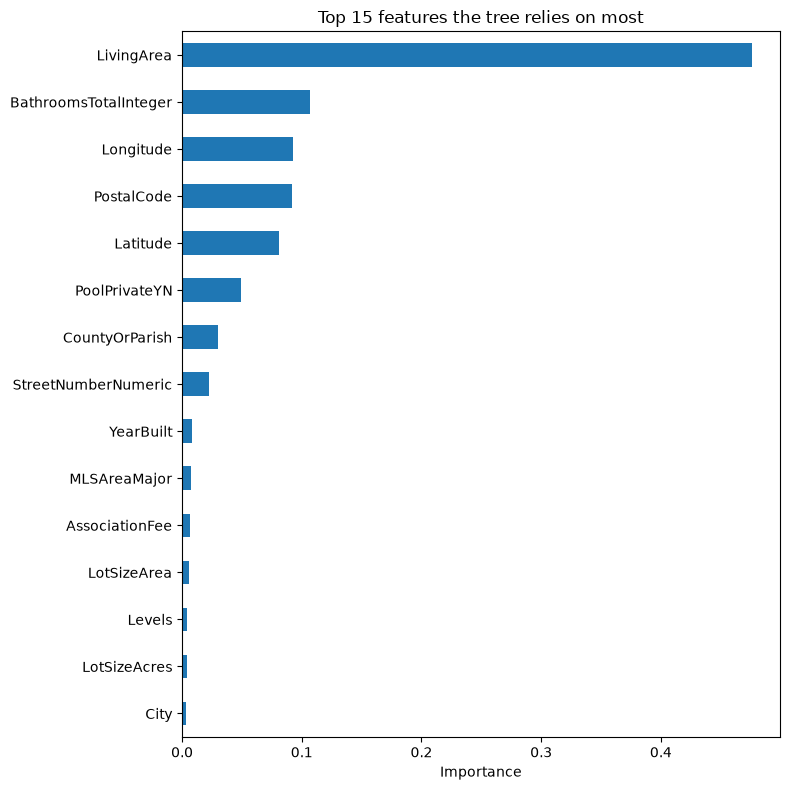

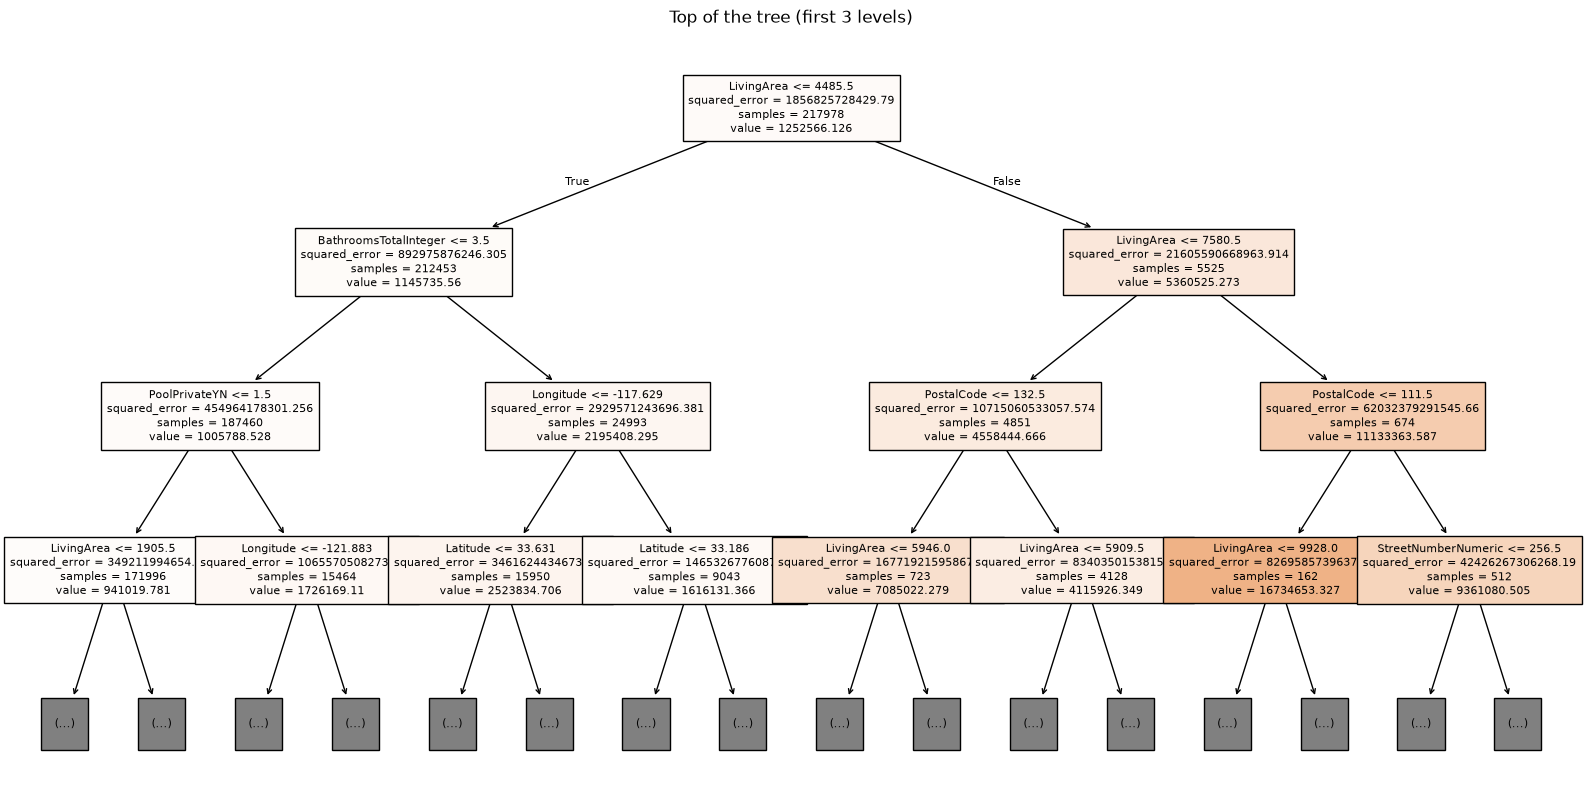

In [5]:
importances = pd.Series(tree_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 8))
importances.head(15).sort_values().plot(kind='barh')
plt.title('Top 15 features the tree relies on most')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

plt.figure(figsize=(20, 10))
tree.plot_tree(tree_model, max_depth=3, feature_names=X_train.columns, filled=True, fontsize=8)
plt.title('Top of the tree (first 3 levels)')
plt.show()

## Save the model

Overwriting `decision_tree_model.pkl` with this run so the file on disk always matches the code that
produced it.

In [6]:
import joblib

joblib.dump(tree_model, 'decision_tree_model.pkl')
print("Saved decision_tree_model.pkl")

Saved decision_tree_model.pkl
